# Biascorrectiion

In [2]:
import xarray as xr
import numpy as np

ds1 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/CMEMS/cmems_new/CMEMS_ph_mask.nc')
ds2 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/SODA/SODA_new/SODA_ph_mask.nc')
lat_range = slice(-30, 30) 
lon_range = slice(30, 120) 

model=xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/Zenodo_Data//ph_cmip6_ensemble_ssp126.nc').ph
subset_ds1 = ds1.sel(lat=lat_range, lon=lon_range)
subset_ds2 = ds2.sel(lat=lat_range, lon=lon_range)

subset_ds1['time'] = subset_ds1.indexes['time'].to_period('M').to_timestamp()
subset_ds2['time'] = subset_ds2.indexes['time'].to_period('M').to_timestamp()

# Interpolate ds2 onto ds1 grid (lat, lon, time)
subset_ds2_interp = subset_ds2.interp(
    lat=subset_ds1['lat'],
    lon=subset_ds1['lon'],
    time=subset_ds1['time'],
    method='linear'
)

# Calculate mean pH
ph_mean = xr.concat(
    [subset_ds1['ph'], subset_ds2_interp['ph']],
    dim='model'
).mean(dim='model')


In [4]:
clim_model=model.sel(time=slice('1985','2014')).groupby('time.month').mean()

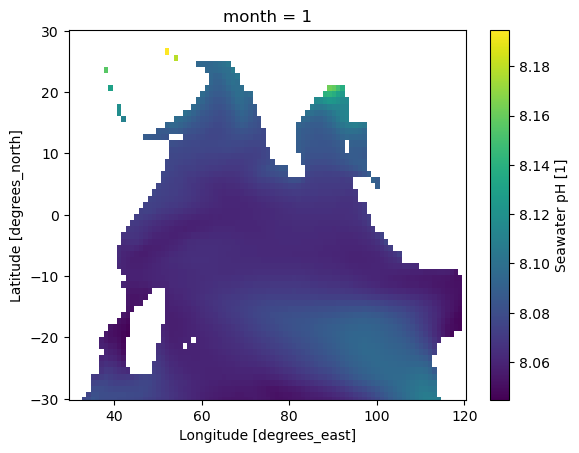

In [5]:
clim_model[0].plot()

In [6]:
repeat=xr.concat([clim_model]*116,dim='month')
repeat['month'] = np.array(model.time)  # pd.DatetimeIndex(gfdl.time)
repeat=repeat.rename({'month':'time'})
delta=model-repeat

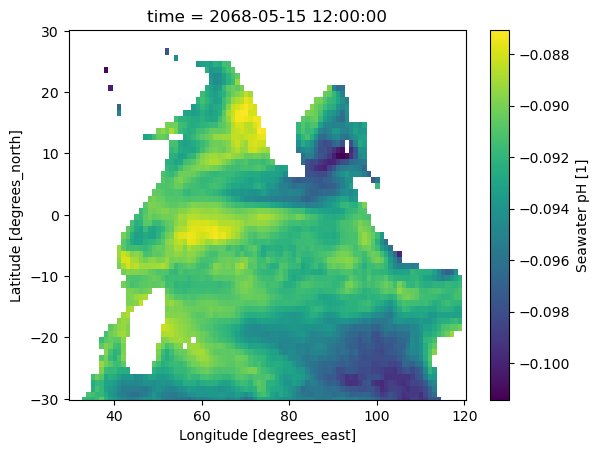

In [7]:
delta[1000].plot()

In [8]:
obs_clim=ph_mean.sel(time=slice('1985','2014')).groupby('time.month').mean()
rep_obs= xr.concat([obs_clim]*116,dim='month')
rep_obs['month']= np.array(model.time) # pd.DatetimeIndex(gfdl.time)
rep_obs=rep_obs.rename({'month':'time'})

In [9]:
delta

<xarray.DataArray 'ph' (time: 1392, lat: 61, lon: 91)> Size: 62MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1392, 61, 91))
Coordinates:
  * time     (time) object 11kB 1985-01-15 12:00:00 ... 2100-12-15 12:00:00
  * lat      (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon      (lon) float32 364B 30.12 31.12 32.12 33.12 ... 118.1 119.1 119.9
Attributes:
    long_name:    Seawater pH
    units:        1
    description:  Seawater surface pH on the total scale

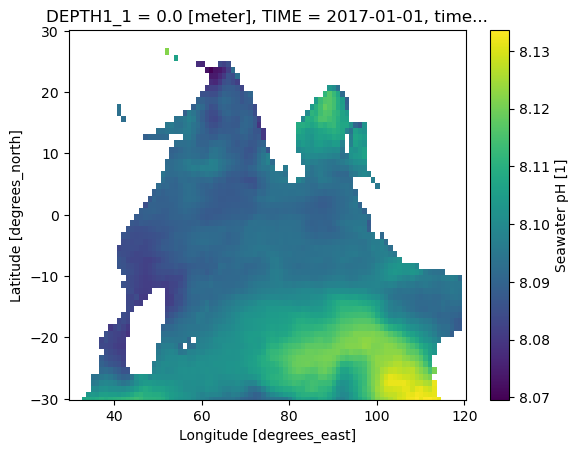

In [10]:
# rep_obs['lon']=delta.lon
rep_obs['lat']=delta.lat

final=rep_obs+delta
final.isel(time=0).plot()
# final.transpose('time', 'lat', 'lon').to_netcdf('ph_ens_ssp126_biascorrected_mean.nc')
